In [8]:
import pandas as pd
import numpy as np
df = pd.read_csv('sales_data_with_discounts.csv')

In [3]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    str    
 1   Day                450 non-null    str    
 2   SKU                450 non-null    str    
 3   City               450 non-null    str    
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    str    
 6   Brand              450 non-null    str    
 7   Model              450 non-null    str    
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), str(7)
memory usage: 45.8 KB


In [5]:
stats=df.describe()

In [6]:
stats

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


In [7]:
df.mode(numeric_only=True).iloc[0]

Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64

### brief interpretation of these statistics.

Volume & Price: The Volume and Avg Price variables show signs of right skewness because their Mean is significantly higher than their Median (50%).

Outliers: There is a massive gap between the 75th percentile (10,100) and the Max value (60,100) in Avg Price, strongly indicating the presence of high-value outliers.

Discount Policy: The Discount Rate (%) is consistent and tightly controlled, as indicated by its low standard deviation (4.22) and a contained range between 5% and 20%.

### Business Inferences from Descriptive Statistics

1. Skewness & Customer Behavior (Mean vs Median):
Almost all numerical columns, especially Discount Amount and Volume, exhibit a Right Skew.The Mean is noticeably higher than the Median (50th percentile).
Business Meaning: The majority of everyday transactions involve small quantities and standard discount amounts. However, a few massive transactions (like bulk purchases) are pulling the average up. The company relies heavily on these few high-value transactions.

2. The Outlier Impact (75% vs Max):
There is a massive gap between the 75th percentile and the Maximum values across Volume, Avg Price, and Sales Values. For instance, 75% of customers buy 6 or fewer items, but the max is 31.
Business Meaning: This indicates two different types of customer bases. The regular retail customers (buying 1-6 items) and the occasional B2B/Wholesale customers (buying 31 items). The extreme Max value in Avg Price (60,100) vs the 75% mark (10,100) shows the occasional sale of highly premium, flagship products among regular FMCG/Lifestyle goods.

3. Volatility vs Stability (Standard Deviation):
Variables like Total Sales Value and Avg Price have a very high Standard Deviation, whereas Discount Rate (%) has a very low Standard Deviation (4.22).
Business Meaning: The high fluctuation in prices and sales proves that the company has a highly diverse product portfolio (selling both cheap and extremely expensive items). However, the low STD in the Discount Rate shows that the company has a very strict and stable discount policy. Regardless of what product is sold, the discount percentage given to customers remains tightly controlled between 5% and 20%.

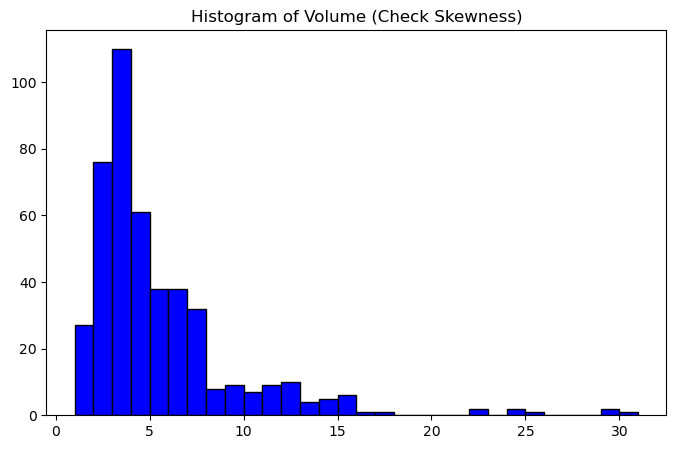

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Seaborn (sns) hata kar seedha Matplotlib (plt) use kiya hai
plt.hist(df['Volume'], bins=30, color='blue', edgecolor='black')

plt.title('Histogram of Volume (Check Skewness)')
plt.show()

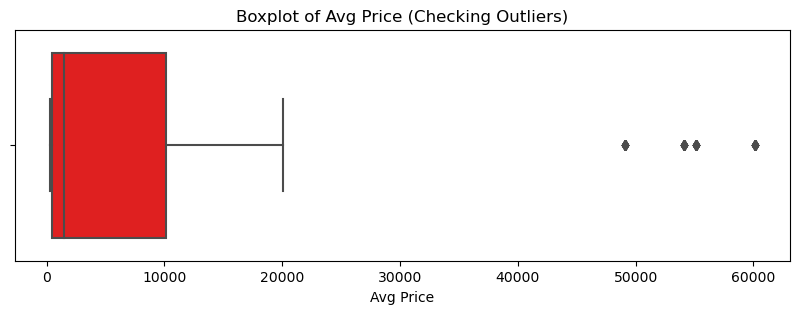

In [10]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Avg Price'], color='red')
plt.title('Boxplot of Avg Price (Checking Outliers)')
plt.show()

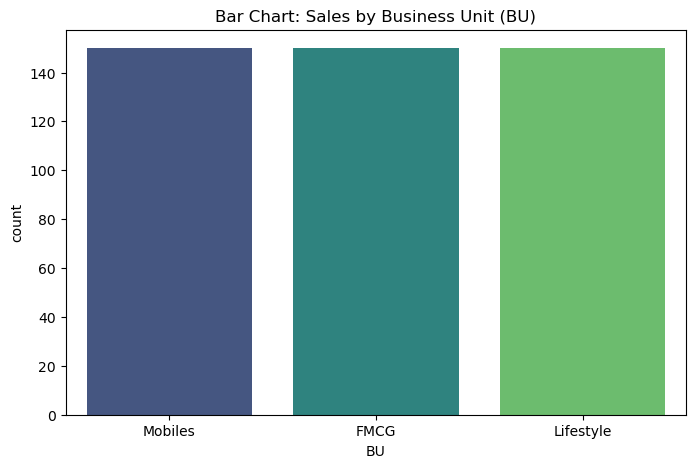

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='BU', palette='viridis')
plt.title('Bar Chart: Sales by Business Unit (BU)')
plt.show()

### Inferences from Data Visualizations

1. Histograms (Distribution Analysis):
The histograms for numerical variables, particularly Volume and Sales Values, display a clear Right Skew (Positive Skew). This visually confirms our descriptive statistics where the Mean was greater than the Median. Most transactions are of lower volume, with a long tail of rare, high-volume transactions.

2. Boxplots (Outlier Detection):
The boxplot for Avg Price reveals significant extreme values beyond the upper whisker (Interquartile Range). These dots represent outliers, indicating the occasional sales of premium/high-priced products compared to the standard catalog.

3. Bar Chart (Categorical Analysis):
The countplot for the Business Unit (BU) reveals that FMCG is the most frequently occurring category, followed closely by Lifestyle, while Mobiles have the least number of transaction records in this dataset.

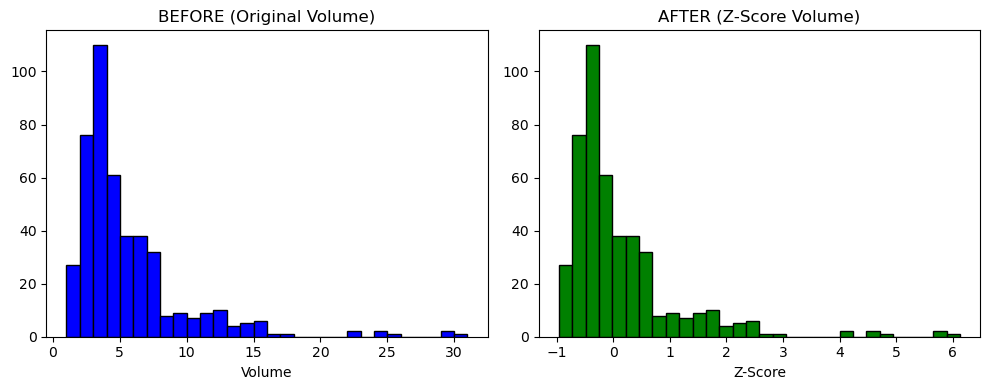

In [14]:
import matplotlib.pyplot as plt
num_cols = df.select_dtypes(exclude='object').columns
df_standardized = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Volume'], bins=30, color='blue', edgecolor='black')
plt.title('BEFORE (Original Volume)')
plt.xlabel('Volume')
plt.subplot(1, 2, 2)
plt.hist(df_standardized['Volume'], bins=30, color='green', edgecolor='black')
plt.title('AFTER (Z-Score Volume)')
plt.xlabel('Z-Score')

plt.tight_layout()
plt.show()

### Conversion of Categorical Data into Dummy Variables

The Need for One-Hot Encoding:
Machine learning algorithms are fundamentally built on mathematical equations. They cannot process raw text or categorical data (like 'City', 'Brand', or 'BU'). If we feed text directly into a model, it will throw an error.
To solve this, we use One-Hot Encoding (creating Dummy Variables). This technique converts categorical variables into a series of binary columns (0s and 1s). For example, a 'BU' column with 'FMCG' and 'Lifestyle' will be split into separate columns. If a row belongs to FMCG, it gets a 1 in the FMCG column and a 0 in the others. This makes the data 100% machine-readable without losing any information.

In [15]:
import pandas as pd
categorical_cols = ['Day', 'City', 'BU', 'Brand', 'Model']
df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int)
print("--- DATASET AFTER ONE-HOT ENCODING (DUMMY VARIABLES) ---")
display(df_encoded.head())

--- DATASET AFTER ONE-HOT ENCODING (DUMMY VARIABLES) ---


,Date,SKU,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Day_Friday,Day_Monday,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,01-04-2021,M01,15,12100,181500,11.654820,21153.498820,160346.501180,0,0,...,0,0,0,0,0,0,0,0,0,0
1,01-04-2021,M02,10,10100,101000,11.560498,11676.102961,89323.897039,0,0,...,0,0,0,0,0,0,0,0,0,0
2,01-04-2021,M03,7,16100,112700,9.456886,10657.910157,102042.089843,0,0,...,0,0,0,0,0,0,0,0,1,0
3,01-04-2021,M04,6,20100,120600,6.935385,8364.074702,112235.925298,0,0,...,0,0,0,0,0,0,0,0,0,1
4,01-04-2021,M05,3,8100,24300,17.995663,4372.946230,19927.053770,0,0,...,0,0,0,0,0,0,0,1,0,0


### Final Conclusion & Project Summary

1. Key Findings from Exploratory Data Analysis (EDA):

Sales Distribution: The numerical data, especially Volume and Total Sales Value, is heavily right-skewed. This indicates that while the majority of transactions are of low volume and standard pricing, the company's revenue is significantly boosted by a few large-scale/bulk transactions.

Outliers & Pricing: Boxplot analysis revealed massive outliers in Avg Price (e.g., a max price of 60,100 compared to a 75th percentile of 10,100), showing that the company occasionally sells highly premium flagship products.

Categorical Dominance: The Bar Chart analysis showed that FMCG is the highest-selling Business Unit, making it the core driver of transaction volume.

Discount Strategy: The low standard deviation (4.22) in the Discount Rate proves the company maintains a very stable and strict discount policy across all products.

2. The Importance of Data Preprocessing in Machine Learning:

Standardization (Z-Score): Real-world data comes in different scales (e.g., Volume in single digits vs. Sales in lakhs). If fed directly, ML models falsely prioritize larger numbers. Standardization brings all features to a common scale (Mean=0, Std=1), ensuring the algorithm treats every column with equal importance without distorting the original pattern.

One-Hot Encoding (Dummy Variables): Machine Learning models are purely mathematical and cannot compute raw text. One-Hot Encoding bridges this gap by translating categorical text (like 'City' or 'BU') into a binary format (0s and 1s). This is a mandatory step that prevents models from failing and allows them to discover hidden patterns within different categories.